In [6]:
股票代码 = '600000'

In [7]:
import akshare as ak
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

In [8]:
df_p = ak.stock_zh_a_hist(symbol=股票代码,period="daily",start_date="20240306",end_date='20250306',adjust='')

In [9]:
df_p

,日期,股票代码,开盘,收盘,最高,最低,成交量,成交额,振幅,涨跌幅,涨跌额,换手率
0,2024-03-06,600000,7.17,7.12,7.22,7.12,259187,185847810.0,1.40,-0.56,-0.04,0.09
1,2024-03-07,600000,7.12,7.14,7.20,7.11,246903,176664369.0,1.26,0.28,0.02,0.08
2,2024-03-08,600000,7.12,7.12,7.17,7.11,198618,141724066.0,0.84,-0.28,-0.02,0.07
3,2024-03-11,600000,7.13,7.11,7.17,7.06,261955,185957986.0,1.54,-0.14,-0.01,0.09
4,2024-03-12,600000,7.11,7.10,7.15,7.08,290305,206425806.0,0.98,-0.14,-0.01,0.10
...,...,...,...,...,...,...,...,...,...,...,...,...
237,2025-02-28,600000,10.23,10.17,10.30,10.17,446511,457102788.0,1.27,-0.68,-0.07,0.15
238,2025-03-03,600000,10.19,10.15,10.22,10.08,430109,436849850.0,1.38,-0.20,-0.02,0.15
239,2025-03-04,600000,10.10,10.10,10.19,10.10,297698,301634439.0,0.89,-0.49,-0.05,0.10
240,2025-03-05,600000,10.14,10.25,10.26,10.05,416864,424730036.0,2.08,1.49,0.15,0.14


In [10]:
df = pd.DataFrame(df_p)

In [11]:
df.set_index('日期', inplace=True)

In [12]:
df['SMA_1'] = df['收盘'].rolling(1).mean()
df['SMA_5'] = df['收盘'].rolling(5).mean()
df['SMA_10'] = df['收盘'].rolling(10).mean()
df['SMA_15'] = df['收盘'].rolling(15).mean()
df['SMA_20'] = df['收盘'].rolling(20).mean()

<Axes: title={'center': ' SMAs'}, xlabel='日期'>

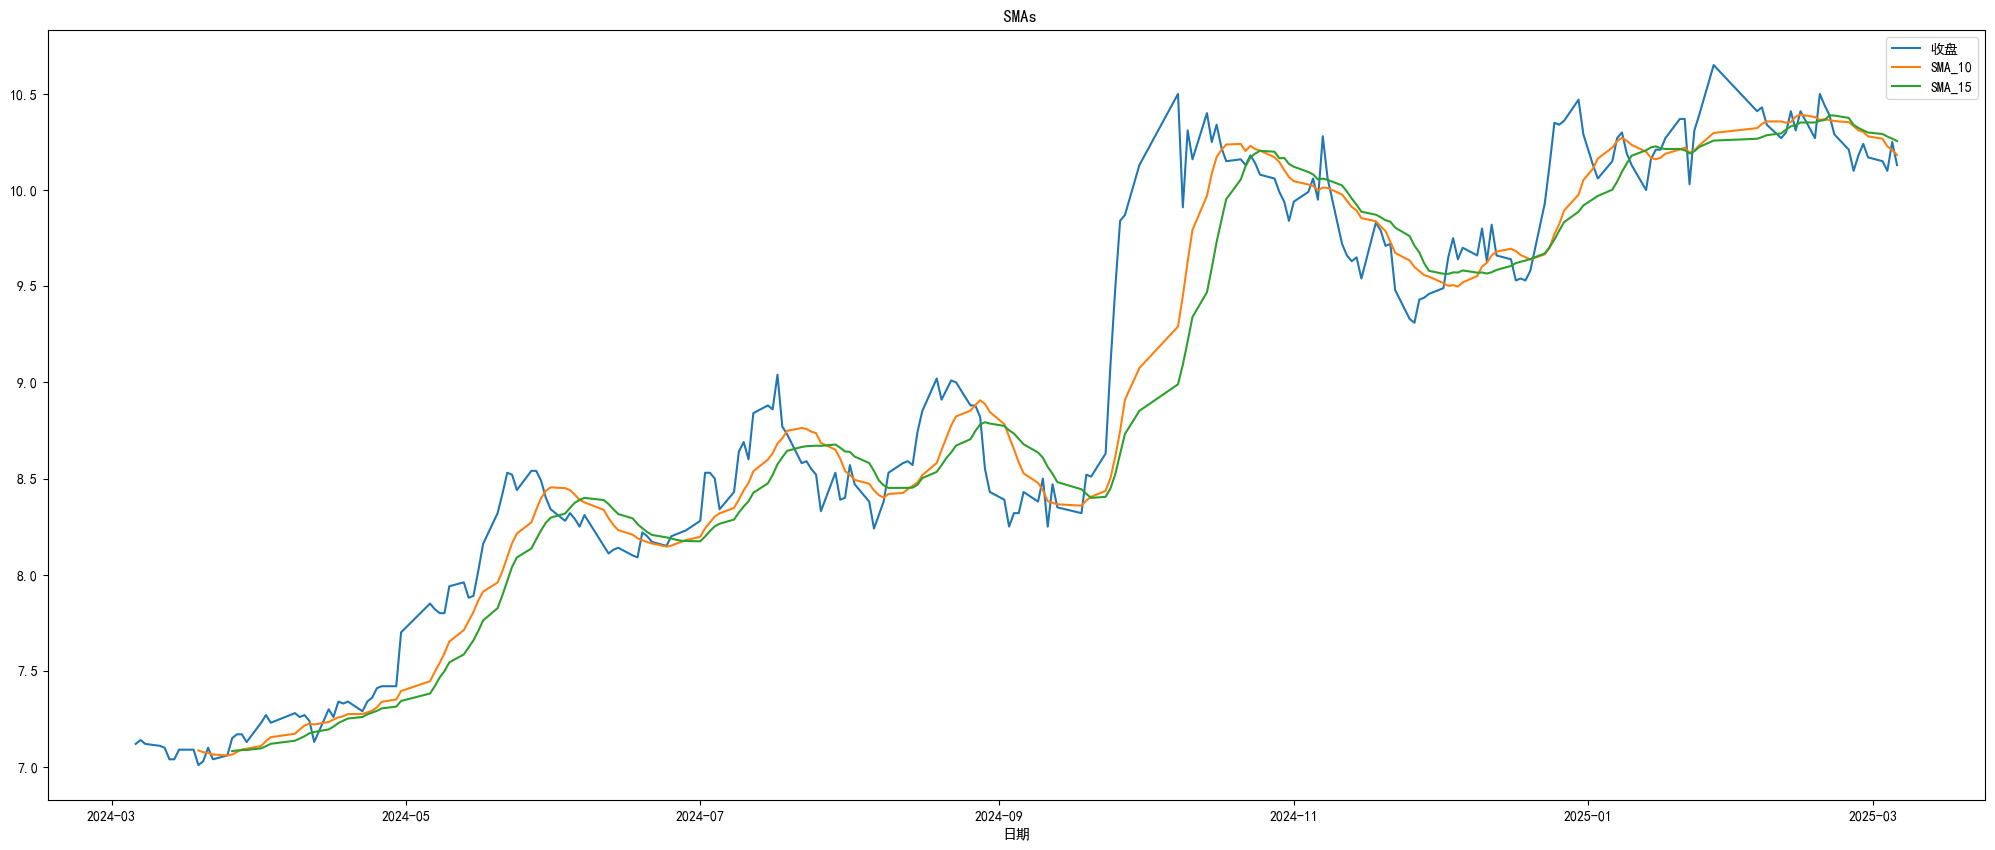

In [13]:
plt.rcParams['font.sans-serif'] = ['SimHei']
df[['收盘','SMA_10','SMA_15']].plot(title=' SMAs',figsize=(25, 10))

In [14]:
df['position']= np.where(df['SMA_10']>df['SMA_15'],1,-1)
df.dropna(inplace=True)
df.head() 

,股票代码,开盘,收盘,最高,最低,成交量,成交额,振幅,涨跌幅,涨跌额,换手率,SMA_1,SMA_5,SMA_10,SMA_15,SMA_20,position
日期,,,,,,,,,,,,,,,,,
2024-04-02,600000,7.24,7.27,7.31,7.22,350952,255236210.0,1.24,0.55,0.04,0.12,7.27,7.194,7.135,7.108000,7.1105,1
2024-04-03,600000,7.23,7.23,7.28,7.19,252541,182860244.0,1.24,-0.55,-0.04,0.09,7.23,7.206,7.155,7.120667,7.1160,1
2024-04-08,600000,7.23,7.28,7.32,7.19,327645,238582732.0,1.80,0.69,0.05,0.11,7.28,7.228,7.173,7.136667,7.1230,1
2024-04-09,600000,7.29,7.26,7.32,7.25,203355,147972234.0,0.96,-0.27,-0.02,0.07,7.26,7.254,7.195,7.148000,7.1300,1
2024-04-10,600000,7.26,7.27,7.33,7.23,224367,163551937.0,1.38,0.14,0.01,0.08,7.27,7.262,7.216,7.160000,7.1380,1


<Axes: title={'center': 'Market Positioning'}, xlabel='日期'>

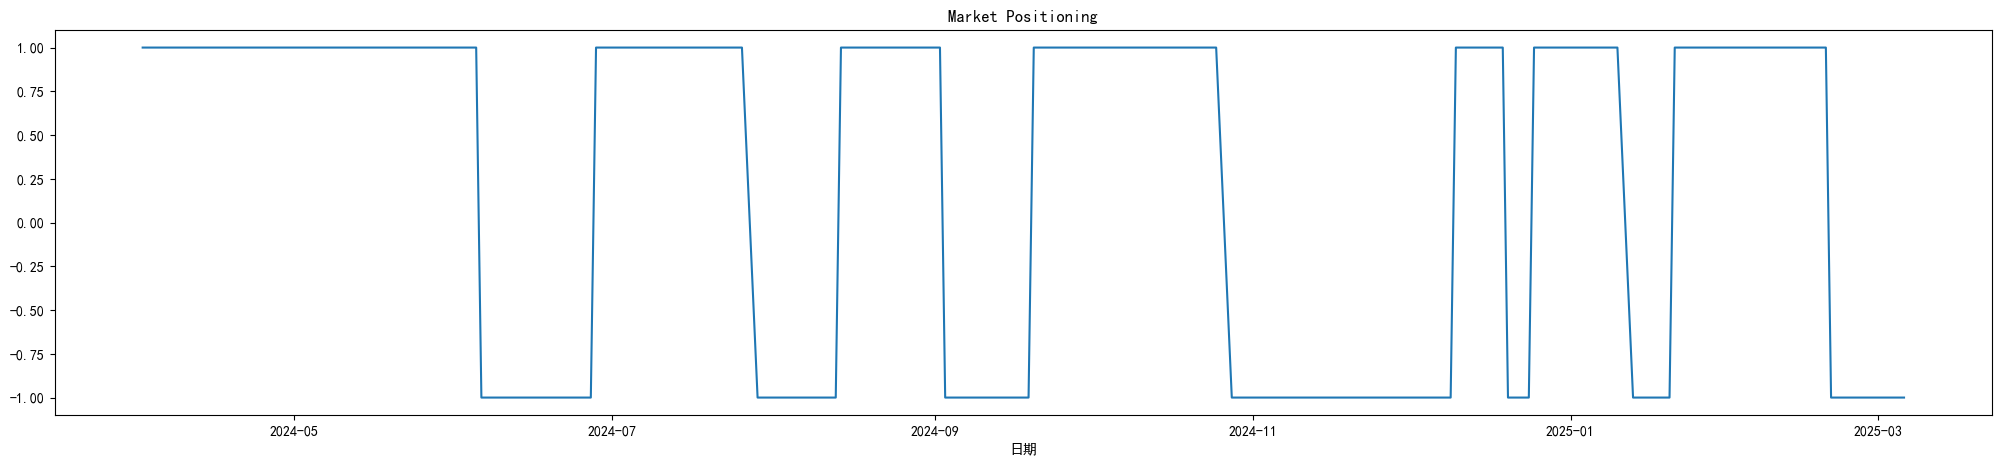

In [15]:
plt.rcParams['axes.unicode_minus'] = False # 显示负号
df['position'].plot(ylim=[-1.1,1.1],figsize=(25,5),title='Market Positioning')

In [16]:
buy = df[df['position'] == 1]
sell = df[df['position'] == -1]

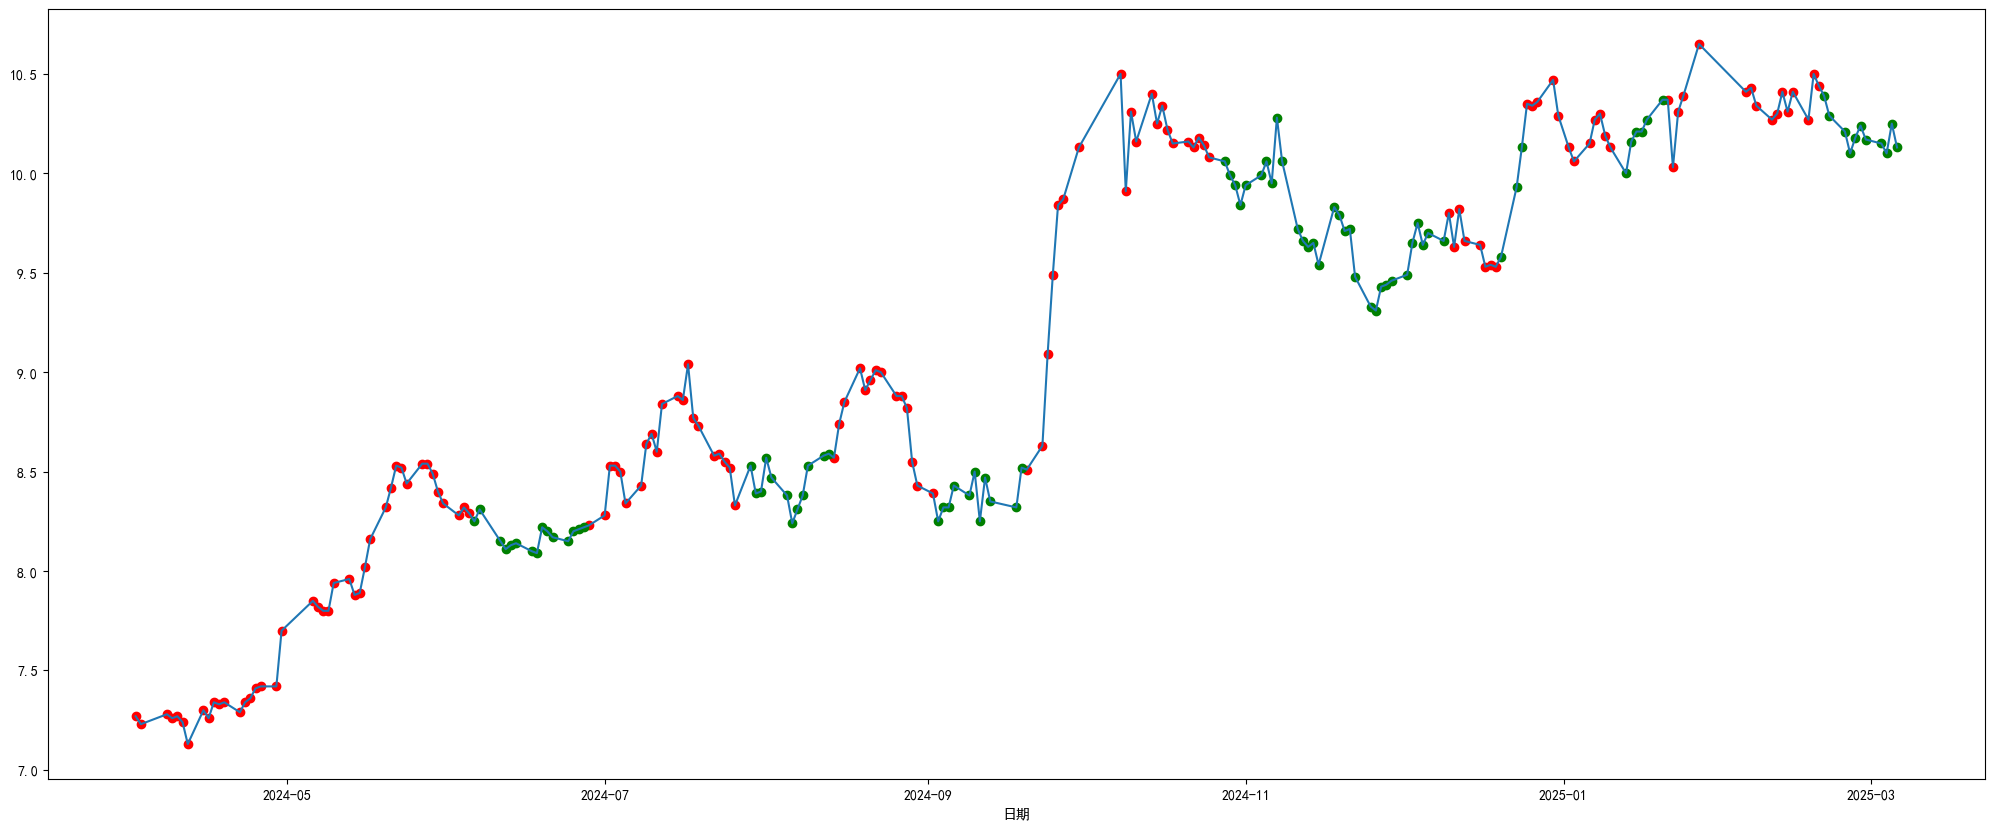

In [17]:
df['收盘'].plot(figsize=(25, 10))
plt.scatter(buy.index, buy['收盘'],color='red')
plt.scatter(sell.index, sell['收盘'],color='green')

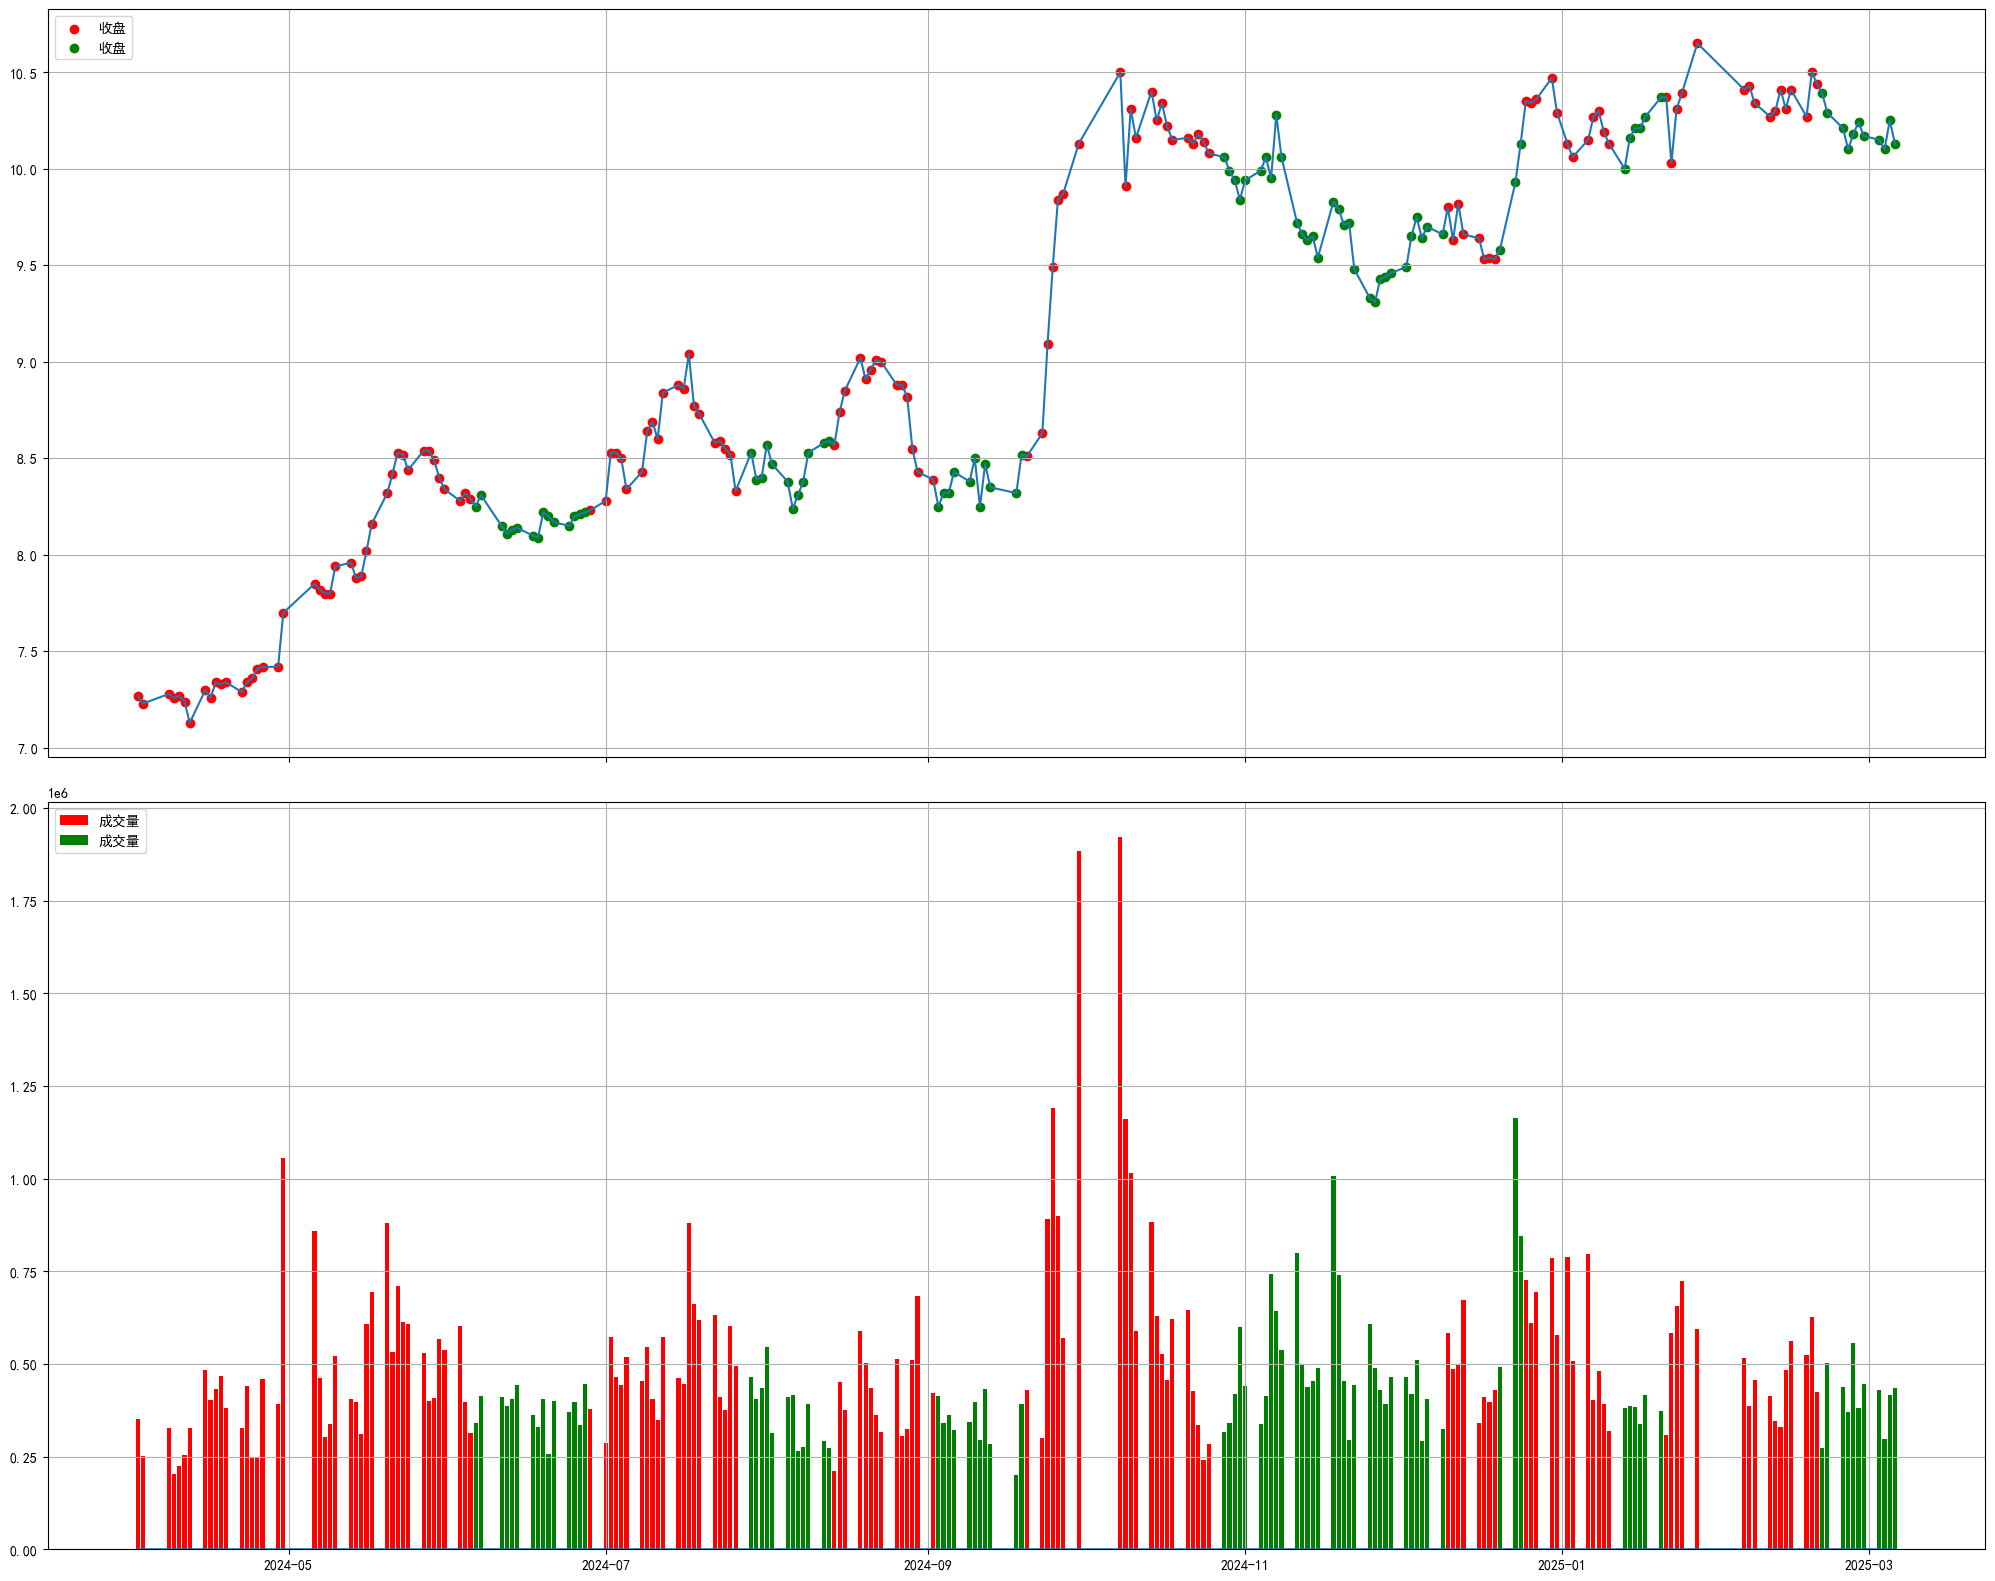

In [18]:
fig, (ax1,ax2) = plt.subplots(2, 1, sharex=True, figsize=(25,20))

ax1.plot(df['收盘'])
ax1.scatter(buy.index, buy['收盘'], color='red', label='收盘')
ax1.scatter(sell.index, sell['收盘'], color='green', label='收盘')
ax1.set_label('收盘')
ax1.legend(loc='upper left')
ax1.grid(True)

ax2.plot(df['收盘'])
ax2.bar(buy.index, buy['成交量'], color='red', label='成交量')
ax2.bar(sell.index, sell['成交量'], color='green', label='成交量')
ax2.set_label('成交量')
ax2.legend(loc='upper left')
ax2.grid(True)

plt.subplots_adjust(hspace=0.06)

In [21]:
df['strategy'] = df['position'].shift(1) * df['涨跌额']
df[['涨跌额','strategy']].sum()

涨跌额         2.90
strategy    1.06
dtype: float64

<Axes: xlabel='日期'>

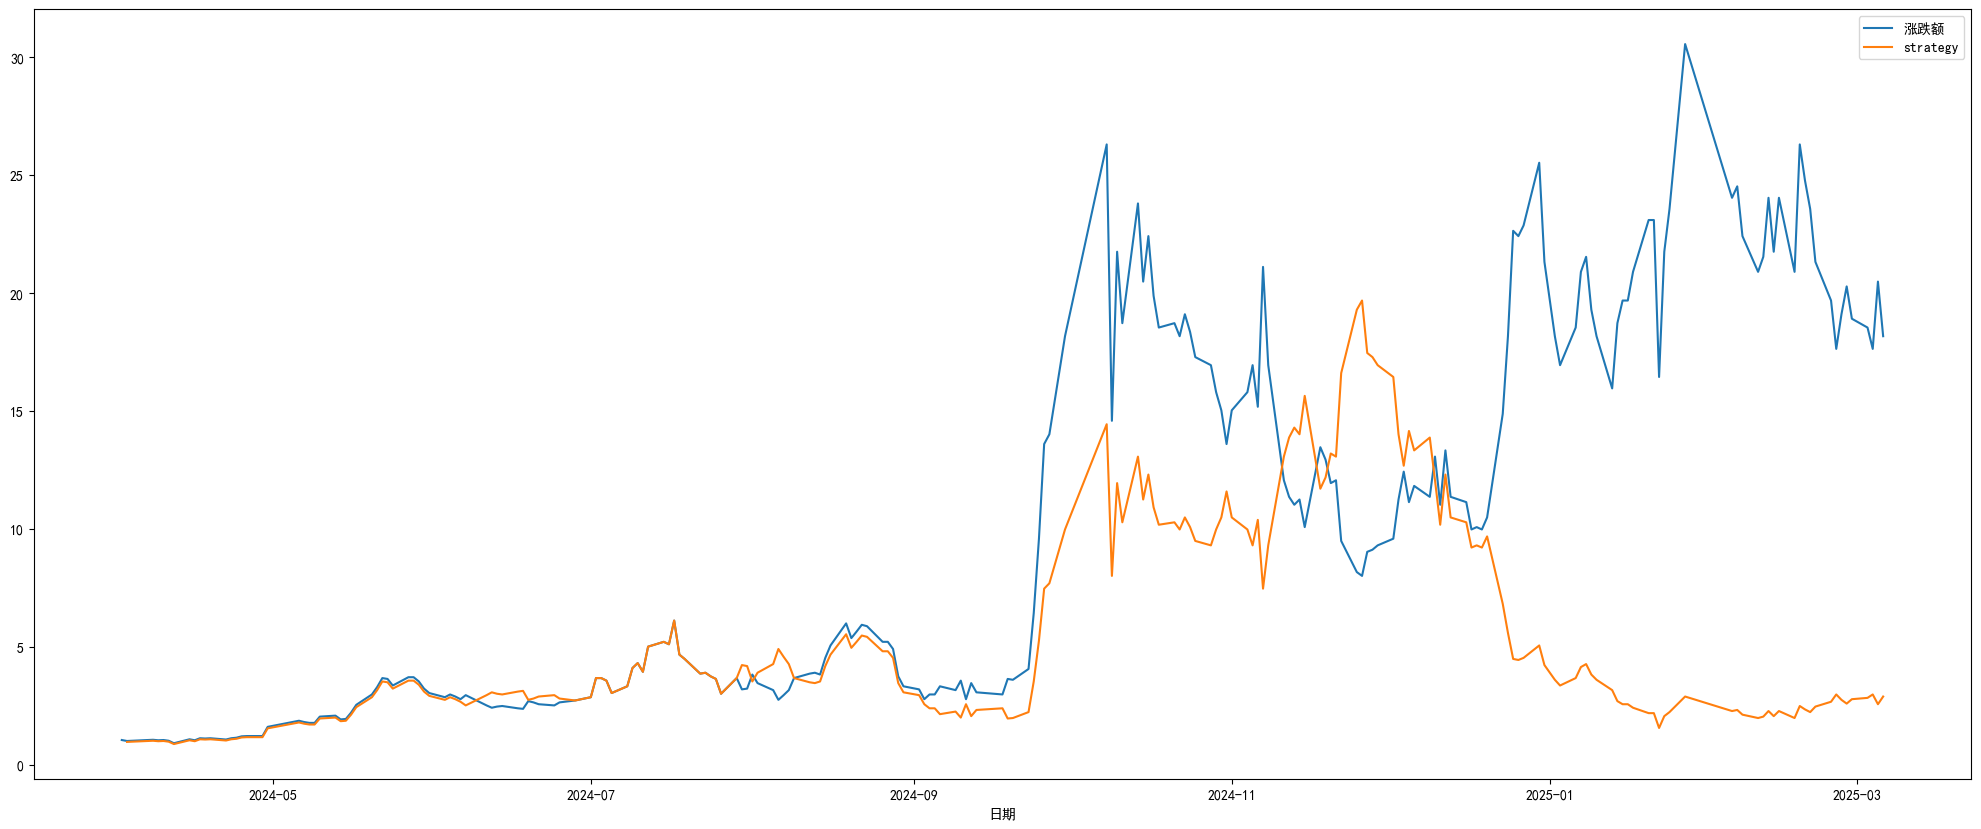

In [22]:
df[['涨跌额','strategy']].cumsum().apply(np.exp).plot(figsize=(25,10))